 # Import required libraries

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering 

# Load and inspect the dataset

In [2]:
df = pd.read_csv("C:/Users/devia/Downloads/smartcart_customers.csv")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.isnull().sum(),  df.duplicated().sum()

(ID                      0
 Year_Birth              0
 Education               0
 Marital_Status          0
 Income                 24
 Kidhome                 0
 Teenhome                0
 Dt_Customer             0
 Recency                 0
 MntWines                0
 MntFruits               0
 MntMeatProducts         0
 MntFishProducts         0
 MntSweetProducts        0
 MntGoldProds            0
 NumDealsPurchases       0
 NumWebPurchases         0
 NumCatalogPurchases     0
 NumStorePurchases       0
 NumWebVisitsMonth       0
 Complain                0
 Response                0
 dtype: int64,
 np.int64(0))

# Data preprocessing 

# 1. Handle Missing Value

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

# Feature Engineering

In [6]:
# Add age columns according to customer birth year
df["Age"] = 2026-df["Year_Birth"]

In [7]:
# Customer Joining Date

df["Dt_Customer"] =pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [9]:
# Total spendings
df["total_spendings"] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [10]:
# children
df["Total_Children"] = df['Kidhome'] + df['Teenhome']

In [11]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({"Basic":"Undergraduate", "2n Cycle":"Undergraduate",
                                           "Graduation":"Graduate",
                                           "PhD": "Postgraduate", "Master":"Postgraduate"
                                           
                                          })
                                           



In [12]:
# Marital Status
df["Marital_Status"].value_counts()

df["Living_With"] =df["Marital_Status"].replace({"Married":"Partner","Together":"Partner",
                                                 "Single":"Alone", "Single":"Alone", "Divorced":"Alone", "Widow":"Alone",
                                                 "Absurd":"Alone", "YOLO":"Alone"
                                                })
                                                 

In [13]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop Columns

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'total_spendings', 'Total_Children', 'Living_With'],
      dtype='str')

In [15]:
cols = ['ID', 'Year_Birth', 'Kidhome', 'Marital_Status', 'Teenhome', 'Dt_Customer'] 
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_to_drop = cols + spending_cols 

df_cleaned =df.drop(columns=cols_to_drop)

In [16]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'total_spendings', 'Total_Children',
       'Living_With'],
      dtype='str')

# Handle Outliers 

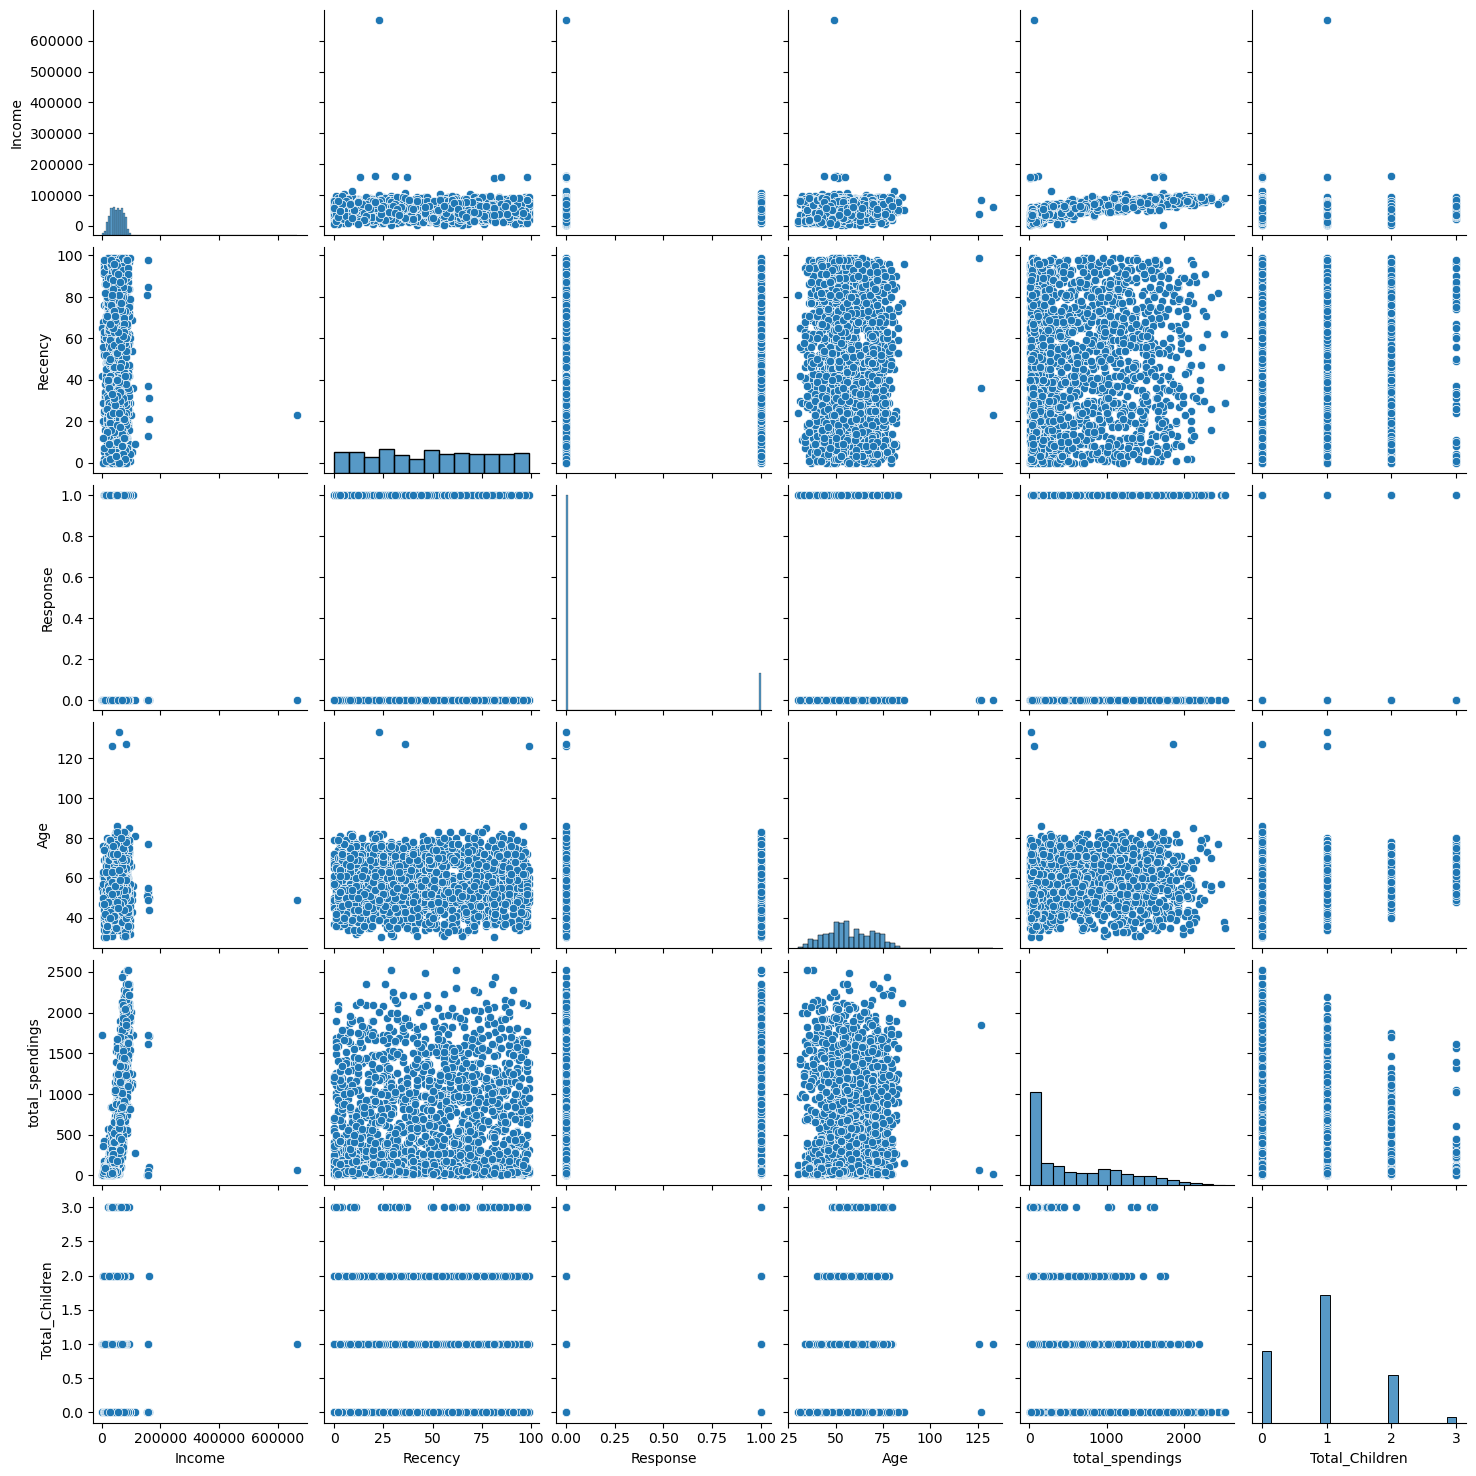

In [17]:
cols = ['Income', 'Recency', 'Response', 'Age', 'total_spendings', 'Total_Children']

# relative plots of some features- pair plots
sns.pairplot(data=df_cleaned[cols])

In [18]:
# Remove outliers
print("data size with outliers:", len(df_cleaned))

cleaned_df = df_cleaned[(df_cleaned["Age"] < 90)]
cleaned_df =cleaned_df[(cleaned_df["Income"] < 600_000)]

print("data size without outliers:", len(cleaned_df))

data size with outliers: 2240
data size without outliers: 2236


# Save cleaned df in csv format

In [19]:
cleaned_df.to_csv("Cleaned Smartcart.csv")

# Compare Size of dataframe

df (2240, 27)
df_cleaned (2240, 15)
cleaned_df (2236, 15)


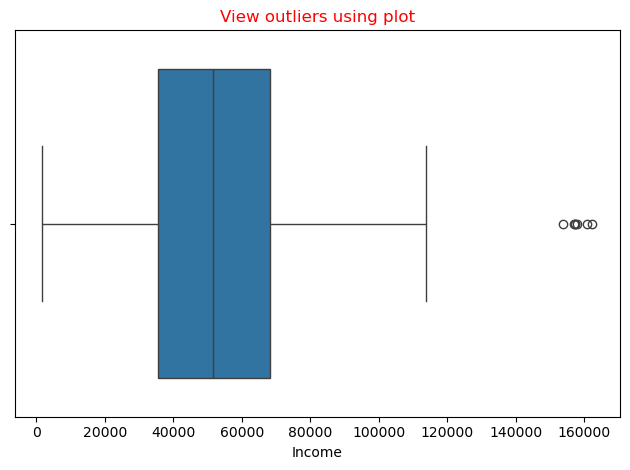

In [20]:

print("df", df.shape)
print("df_cleaned", df_cleaned.shape)
print("cleaned_df", cleaned_df.shape)

sns.boxplot(x=cleaned_df["Income"])
plt.title("View outliers using plot", color="red")
plt.tight_layout()
plt.show()


# HeatMap

<Axes: >

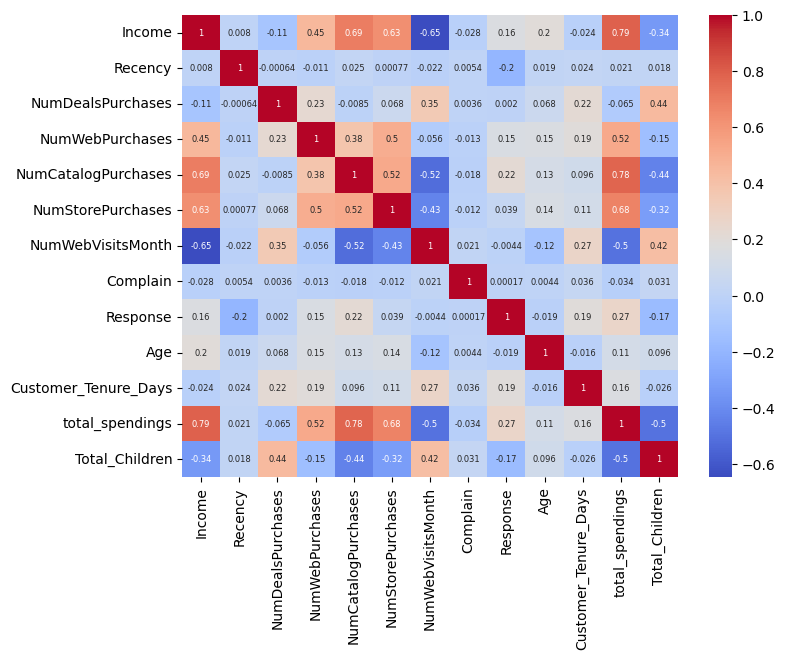

In [21]:
corr = cleaned_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            annot_kws={"size":6}
           )

# Encoding and Scaling


In [22]:
hoe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_cols = ["Education", 'Living_With']
enc_cols = hoe.fit_transform(cleaned_df[cat_cols])

enc_df = pd.DataFrame(enc_cols, columns = hoe.get_feature_names_out(cat_cols), index= cleaned_df.index)

encoded_df = pd.concat([cleaned_df.drop(columns=cat_cols), enc_df], axis=1)

In [23]:
encoded_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spendings,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Save Encoded Df in csv format

In [45]:
encoded_df.to_csv("Encoded Smartcart.csv")

In [24]:
X= encoded_df

In [25]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)

# Visualize

In [26]:
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

[0.23162286 0.11385437]


<Axes: >

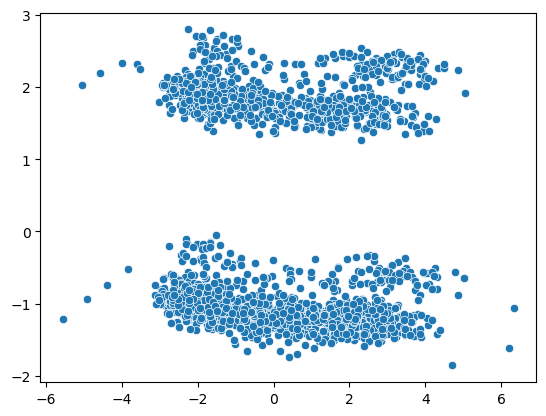

In [27]:
print(pca.explained_variance_ratio_)
#2D 
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1])

In [28]:
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)


Text(0.5, 0.92, '3D Projection')

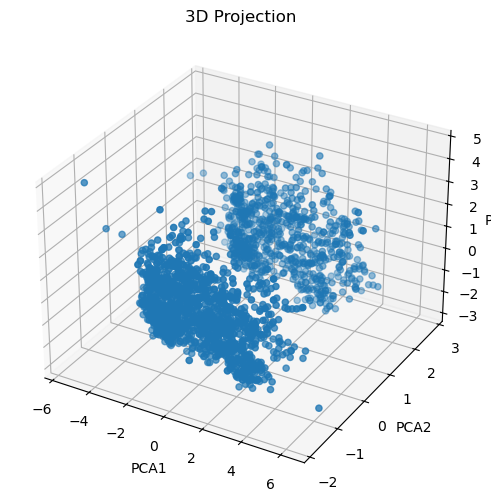

In [29]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")


# Analyze K value

# 1. Elbow Method

In [30]:
wcss = []
for k in range(1, 11):
    kmeans =  KMeans(n_clusters=k,
                     random_state=42
                    )
    label = kmeans.fit_predict(x_scaled)

    wcss.append(kmeans.inertia_)

In [31]:
knee = KneeLocator(range(1,11), 
                   wcss, 
                   curve="convex", 
                   direction="decreasing"
                  )
optimal_k = knee.elbow

print("optimal_k = ", optimal_k)

optimal_k =  4


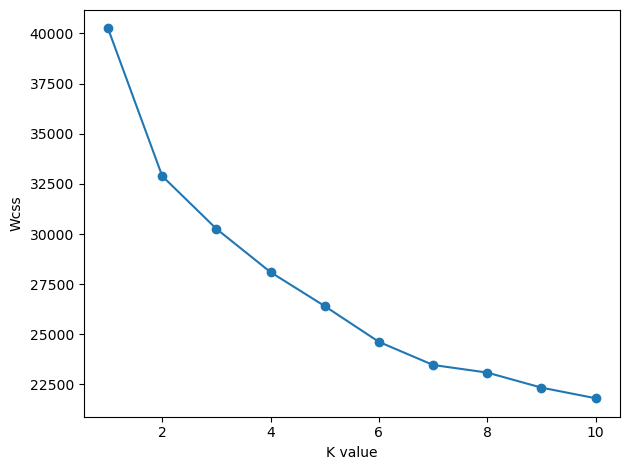

In [32]:
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K value")
plt.ylabel("Wcss")
plt.tight_layout()
plt.show()

In [33]:
scores = []

for k in range(2, 11):
    kmeans =  KMeans(n_clusters=k,
                     random_state=42
                    )
    label = kmeans.fit_predict(x_pca)
    ss= silhouette_score(x_pca, label)
    scores.append(ss)

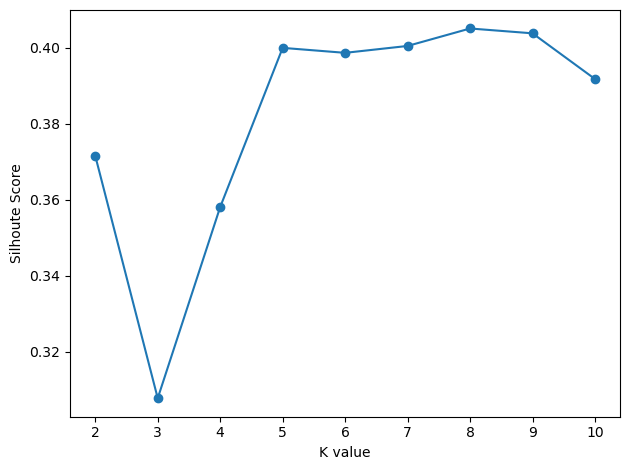

In [34]:
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K value")
plt.ylabel("Silhoute Score")
plt.tight_layout()
plt.show()

In [35]:
# Combined plot

Text(0, 0.5, 'Silhouette Scores')

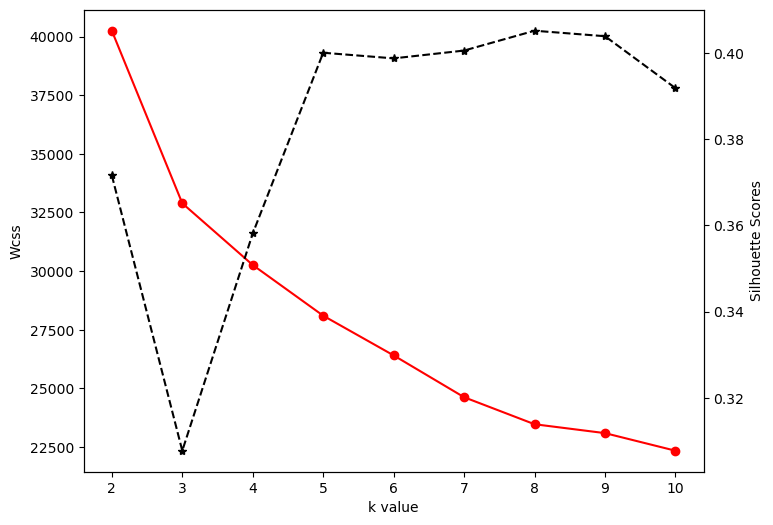

In [36]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot((k_range), wcss[:len(k_range)], marker="o", color="red")
ax1.set_xlabel("k value")
ax1.set_ylabel("Wcss")

ax2 = ax1.twinx()
ax2.plot((k_range), scores[:len(k_range)], marker="*", color="black", linestyle="--")
ax2.set_xlabel("k value")
ax2.set_ylabel("Silhouette Scores")


# Clustering

In [37]:
kmeans =  KMeans(n_clusters=4,
                     random_state=42
                    )
labels = kmeans.fit_predict(x_pca)

Text(0.5, 0.92, '3D Projection')

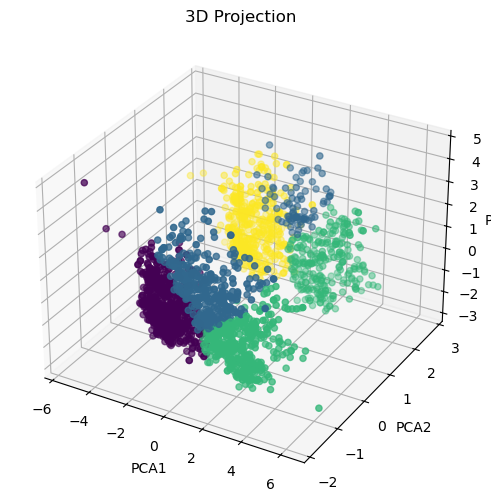

In [38]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2], c=labels )
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

# Agglomerative clustering

Text(0.5, 0.92, '3D Projection')

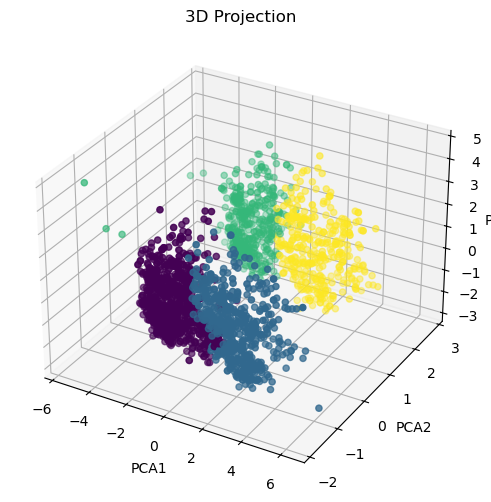

In [39]:
agg = AgglomerativeClustering(n_clusters=4,
                            linkage="ward"
                           )
label = agg.fit_predict(x_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:, 0],x_pca[:, 1],x_pca[:, 2], c=label)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")


# characterization of Clusters

In [40]:

X["cluster"] = label

In [41]:
cleaned_df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spendings,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


<Axes: xlabel='cluster', ylabel='count'>

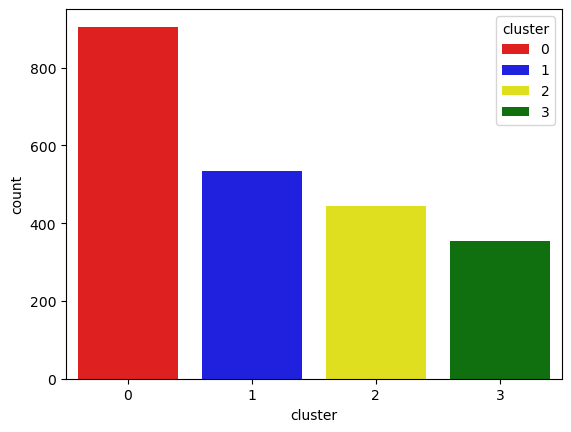

In [42]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='total_spendings', ylabel='Income'>

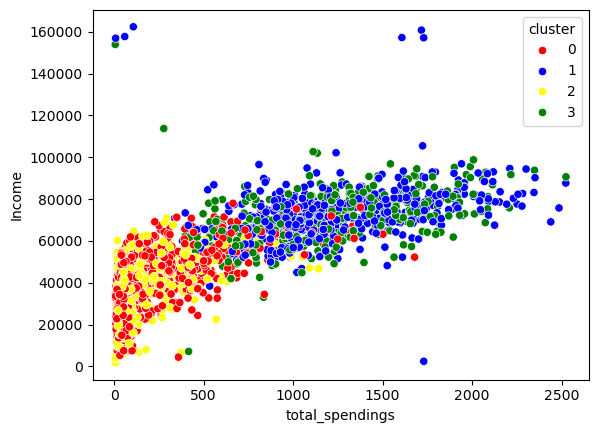

In [43]:
# Income & spending 
sns.scatterplot(x=X['total_spendings'], y=X['Income'], palette=pal, hue=X["cluster"])

# Cluster Summery

In [44]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39690.146424  48.914917           2.594475         3.153591   
1        72814.930722  49.202247           1.958801         5.687266   
2        36973.792251  48.319820           2.594595         2.713964   
3        70730.038963  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  total_spendings  \
cluster        

In [48]:
X.to_csv("With Cluster.csv")